In [29]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [48]:
sys.path.insert(0, "..")
sys.path.insert(0, os.path.abspath("../src"))
 
from src.features import build_features, FEATURES
from src.labels import rebalance_dates, make_labels
from src.models import walk_forward_predict, rank_ic
from src.backtester import (
    run_backtest, month_end_trading_dates,
    compute_forward_returns, compute_rank_ic,
)
from src.risk import risk_adapter
 
MODEL = "rf"                # swapped to "logit" / "rf"/"ridge" to compare models
EVAL_START, EVAL_END = "2023-01-01", "2024-12-31"
WINDOWS = {
    "validation_2023": ("2023-01-01", "2023-12-31"),
    "test_2024":       ("2024-01-01", "2024-12-31"),
}


In [49]:
df = pd.read_parquet("../data/ohlcv.parquet")
df["date"] = pd.to_datetime(df["date"])
prices = df[["date", "ticker", "close"]].copy()   # all the backtester needs
n_universe = df["ticker"].nunique()
IS_PLUMBING = n_universe < 50
 
if IS_PLUMBING:
    print(f"  PLUMBING DRY RUN — universe = {n_universe} names")
    print("  Numbers below validate the INTEGRATION, they are NOT results.")
    print(f"  IC on a {n_universe}-name cross-section is statistically meaningless.")
    print("  Expand data.py TICKERS to 60-100, regenerate the parquet, and")
    print("  re-run this notebook UNCHANGED for interpretable results.")
else:
    print(f"  REAL RUN — universe = {n_universe} names")


  REAL RUN — universe = 91 names


In [50]:
rb = rebalance_dates(df["date"])
feats = build_features(df)
labels = make_labels(df, rb)
data = feats.join(labels, how="inner").dropna()
 
label_end = labels["label_end"].groupby(level="date").first()
label_end = pd.Series(pd.to_datetime(label_end.values),
                      index=pd.DatetimeIndex(label_end.index))
 
print("data rows:", len(data), "| rebalance dates:", len(rb))
print("features:", FEATURES)
 
 
# --- CELL 4: THE BRIDGE — walk-forward scores -> backtester input ----------
pred, fit_log = walk_forward_predict(
    data, FEATURES, label_end, name=MODEL,
    eval_start=EVAL_START, eval_end=EVAL_END,
)
scores = pred.reset_index()[["date", "ticker", "score"]].copy()
scores["date"] = pd.to_datetime(scores["date"])
print(f"model={MODEL} | prediction rows: {len(pred)} | scored dates: {scores['date'].nunique()}")
print(scores.head())

d:\Cross-sectional-alpha-ranking\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


data rows: 10494 | rebalance dates: 127
features: ['ret_5', 'ret_20', 'ret_60', 'vol_20', 'relvol_20', 'rsi_14', 'macd_norm']


d:\Cross-sectional-alpha-ranking\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Cross-sectional-alpha-ranking\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Cross-sectional-alpha-ranking\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Cross-sectional-alpha-ranking\.venv\Lib\site-packages\s

model=rf | prediction rows: 2093 | scored dates: 23
        date         ticker     score
0 2023-01-31         ABB.NS  0.487402
1 2023-01-31    ADANIENT.NS  0.499388
2 2023-01-31  ADANIGREEN.NS  0.480273
3 2023-01-31  ADANIPORTS.NS  0.498887
4 2023-01-31  ADANIPOWER.NS  0.514141


In [51]:
their_ic = rank_ic(pred)
our_ic = pd.Series({d: compute_rank_ic(g["score"], g["fwd_ret"])
                    for d, g in pred.groupby(level="date")}, name="rank_ic")
ic_seam = (their_ic.sort_index() - our_ic.sort_index()).abs().max()
 
# (b) labels' fwd_ret == backtester's fwd_ret (so IC and P&L reconcile)
bt_fwd = compute_forward_returns(df, month_end_trading_dates(df["date"]))
sd = scores["date"].iloc[0]
lab = pred.xs(sd, level="date")["fwd_ret"]
fwd_seam = (lab - bt_fwd.loc[sd].reindex(lab.index)).abs().max()
 
print(f"[seam a] max |model_IC - backtester_IC| = {ic_seam:.2e}")
print(f"[seam b] max |labels_fwd - backtester_fwd| = {fwd_seam:.2e}")
assert ic_seam < 1e-9, "IC calculations disagree"
assert fwd_seam < 1e-9, "forward-return definitions disagree"
print("SEAMS OK — model and backtester compute identical IC on identical returns.")
 


[seam a] max |model_IC - backtester_IC| = 0.00e+00
[seam b] max |labels_fwd - backtester_fwd| = 0.00e+00
SEAMS OK — model and backtester compute identical IC on identical returns.


In [52]:
baseline = run_backtest(
    prices, scores,
    rebalance_dates=month_end_trading_dates(df["date"]),
    eval_start=EVAL_START, eval_end=EVAL_END,
    risk_fn=None, strict=True,
)
print("PHASE C (no risk):", len(baseline.periods), "periods,",
      len(baseline.skipped), "skipped")
base_verdict = baseline.by_window(WINDOWS)
print(base_verdict.loc[["n_periods", "mean_IC", "ICIR", "IC_hit_rate",
                        "sharpe", "sortino", "max_drawdown", "ann_return",
                        "mean_turnover", "information_ratio"]].round(4).to_string())
 
 

PHASE C (no risk): 23 periods, 0 skipped
                   validation_2023  test_2024
n_periods                  12.0000    11.0000
mean_IC                     0.0057    -0.0674
ICIR                        0.0474    -0.5746
IC_hit_rate                 0.5000     0.2727
sharpe                      1.0091    -1.0456
sortino                     2.5039    -1.2209
max_drawdown               -0.0451    -0.1181
ann_return                  0.0733    -0.1093
mean_turnover               1.6574     1.6263
information_ratio          -2.4605    -1.3685


In [53]:
v = baseline.by_window(WINDOWS)
ic_2023 = v.loc["mean_IC", "validation_2023"]
ic_2024 = v.loc["mean_IC", "test_2024"]
stable_sign = np.sign(ic_2023) == np.sign(ic_2024)
both_pos = (ic_2023 > 0) and (ic_2024 > 0)
 
print(f"2023 mean IC = {ic_2023:+.4f} | 2024 mean IC = {ic_2024:+.4f}")
if both_pos and stable_sign:
    print("VERDICT: IC positive in both windows — signal is stable and worth pursuing.")
elif stable_sign:
    print("VERDICT: IC same sign both windows but not both positive — weak/ambiguous.")
else:
    print("VERDICT: IC FLIPS SIGN between validation and test — signal is UNSTABLE.")
if IS_PLUMBING:
    print(f"(Caveat: {n_universe}-name universe — treat as plumbing, not evidence.)")


2023 mean IC = +0.0057 | 2024 mean IC = -0.0674
VERDICT: IC FLIPS SIGN between validation and test — signal is UNSTABLE.


In [36]:
risk_diag = {"calls": 0, "changed": 0}
def tracked_risk(weights, daily_returns, nav_history):
    adj = risk_adapter(weights, daily_returns, nav_history)
    risk_diag["calls"] += 1
    if not np.allclose(weights.reindex(adj.index, fill_value=0.0).to_numpy(),
                       adj.to_numpy(), rtol=1e-10, atol=1e-10):
        risk_diag["changed"] += 1
    return adj
 
risk_on = run_backtest(
    prices, scores,
    rebalance_dates=month_end_trading_dates(df["date"]),
    eval_start=EVAL_START, eval_end=EVAL_END,
    risk_fn=tracked_risk, strict=True,
)
print("PHASE D (risk on):", len(risk_on.periods), "periods,",
      len(risk_on.skipped), "skipped")
print(f"risk hook called {risk_diag['calls']}x, changed sizing {risk_diag['changed']}x")


PHASE D (risk on): 23 periods, 0 skipped
risk hook called 23x, changed sizing 9x


In [37]:
ic_diff = np.nanmax(np.abs(
    baseline.periods["rank_ic"].to_numpy() - risk_on.periods["rank_ic"].to_numpy()
))
print(f"max |baseline IC - risk IC| = {ic_diff:.2e}")
assert np.allclose(baseline.periods["rank_ic"].to_numpy(),
                   risk_on.periods["rank_ic"].to_numpy(), equal_nan=True), \
    "RISK LAYER CHANGED IC — bug: risk must not touch rankings"
print("GATE 1 PASSED — risk management leaves the signal ranking untouched.")


max |baseline IC - risk IC| = 0.00e+00
GATE 1 PASSED — risk management leaves the signal ranking untouched.


In [38]:
b, r = baseline.summary(), risk_on.summary()
comparison = pd.DataFrame({"Baseline (no risk)": b, "Risk-adjusted": r})
print(comparison.loc[["ann_vol", "max_drawdown", "mean_turnover",
                      "sharpe", "sortino", "mean_IC", "final_nav"]].round(4).to_string())
print(f"\nvol: {b['ann_vol']:.4f} -> {r['ann_vol']:.4f} | "
      f"maxDD: {b['max_drawdown']:.4f} -> {r['max_drawdown']:.4f} | "
      f"turnover: {b['mean_turnover']:.4f} -> {r['mean_turnover']:.4f}")
if abs(r["ann_vol"]) <= abs(b["ann_vol"]) + 1e-9:
    print("GATE 2 PASSED — risk layer reduced (or held) volatility, as intended.")
else:
    print("GATE 2 NOTE — risk-adjusted vol is higher; investigate.")


               Baseline (no risk)  Risk-adjusted
ann_vol                    0.1263         0.1223
max_drawdown              -0.1681        -0.1558
mean_turnover              1.5072         1.4737
sharpe                    -0.0225         0.0147
sortino                   -0.0344         0.0225
mean_IC                    0.0070         0.0070
final_nav                  0.9801         0.9898

vol: 0.1263 -> 0.1223 | maxDD: -0.1681 -> -0.1558 | turnover: 1.5072 -> 1.4737
GATE 2 PASSED — risk layer reduced (or held) volatility, as intended.


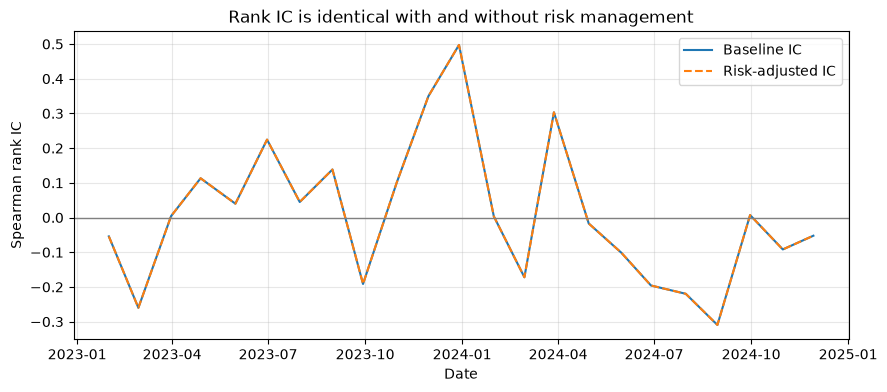

In [39]:
plt.figure(figsize=(10, 4))
plt.plot(baseline.periods["date"], baseline.periods["rank_ic"], label="Baseline IC")
plt.plot(risk_on.periods["date"], risk_on.periods["rank_ic"],
         linestyle="--", label="Risk-adjusted IC")
plt.axhline(0, linewidth=1, color="grey")
plt.xlabel("Date"); plt.ylabel("Spearman rank IC")
plt.title("Rank IC is identical with and without risk management")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

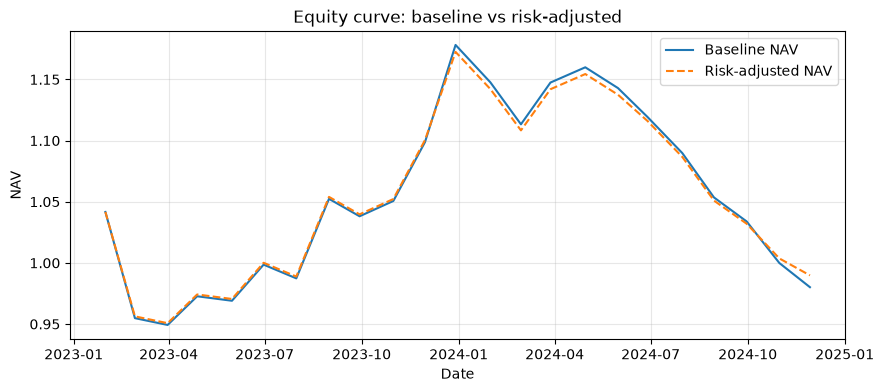

In [40]:
plt.figure(figsize=(10, 4))
plt.plot(baseline.periods["date"], baseline.periods["nav"], label="Baseline NAV")
plt.plot(risk_on.periods["date"], risk_on.periods["nav"],
         linestyle="--", label="Risk-adjusted NAV")
plt.xlabel("Date"); plt.ylabel("NAV")
plt.title("Equity curve: baseline vs risk-adjusted")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()


In [41]:
print("PHASE C / D SUMMARY")
print("-" * 60)
print(f"model: {MODEL} | universe: {n_universe} names"
      + ("  (PLUMBING — not results)" if IS_PLUMBING else ""))
print(f"seam checks: IC {ic_seam:.0e}, fwd_ret {fwd_seam:.0e} (both 0 = clean)")
print(f"IC-invariant under risk: {ic_diff:.0e} (0 = risk didn't touch ranking)")
print(f"risk effect: vol {b['ann_vol']:.3f}->{r['ann_vol']:.3f}, "
      f"maxDD {b['max_drawdown']:.3f}->{r['max_drawdown']:.3f}")
print("-" * 60)
print("Risk management changes sizing and the P&L profile, never the signal.")
if IS_PLUMBING:
    print(f"Re-run after expanding to 60-100 names for interpretable alpha numbers.")


PHASE C / D SUMMARY
------------------------------------------------------------
model: ridge | universe: 91 names
seam checks: IC 0e+00, fwd_ret 0e+00 (both 0 = clean)
IC-invariant under risk: 0e+00 (0 = risk didn't touch ranking)
risk effect: vol 0.126->0.122, maxDD -0.168->-0.156
------------------------------------------------------------
Risk management changes sizing and the P&L profile, never the signal.
